# **IndiGo Airlines: Maximising On-Time Arrival Rate (OTAR) through Operational** **Efficiency**

In [ ]:
###  Auto-Setup Cell (Hidden — Don't Delete)
# SETUP CELL: This block loads the dataset and essential libraries
# It is designed to auto-run at the start of every Colab session and stay hidden.
# Hides out put of this cell.
%%capture
#  Installing gdown to download datasets directly from Google Drive
!pip install -q gdown  # -q = quiet install, to reduce output noise

# 📚 Importing Essential LibrariesS

import gdown  # For downloading files from Google Drive
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations and handling arrays
import matplotlib.pyplot as plt  # For basic plotting and visualizations
import seaborn as sns  # For advanced visualizations and statistical plots
import warnings  # To manage and suppress warning messages

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

#  Style setting for better-looking plots
sns.set(style="whitegrid")
# This code downloads the flights dataset and loads it into a DataFrame
import gdown
import pandas as pd
file_id = "1EVaaJi4SqJ6V1U_KA_d1xEU-SOnUEV_3"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "flights_dataset.csv"
gdown.download(download_url, output_file, quiet=False)
data = pd.read_csv(output_file)
flights_df = pd.read_csv(output_file)

import gdown
import pandas as pd
file_id = "1ain4miP35LPzrOgVM0suUK1YzJB9JevO"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "airports_dataset.csv"
gdown.download(download_url, output_file, quiet=False)
data = pd.read_csv(output_file)
airports_df = pd.read_csv(output_file)

import gdown
import pandas as pd
file_id = "1IMyIql0ktMmrm-3F6NMBPom2IdWvyB69"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "airlines_dataset.csv"
gdown.download(download_url, output_file, quiet=False)
data = pd.read_csv(output_file)
airlines_df = pd.read_csv(output_file)

# **Business Problem Overview**

##  ***Introduction***

IndiGo Airlines, India’s leading low-cost carrier, has recently expanded its operations into the U.S. domestic aviation market. Back home, the airline has built a strong reputation for its punctuality and efficient operations. But entering the U.S. brings a new set of challenges. The American aviation space is far more complex—crowded airports, unpredictable weather, and tighter regulatory requirements make it a much tougher environment to navigate.

To gain a foothold and win the trust of U.S. travelers, IndiGo needs to prove it can deliver consistent, reliable service. A key measure of this is the On-Time Arrival Rate (OTAR)—the percentage of flights that land on or before their scheduled arrival time. Maintaining a high OTAR doesn’t just improve customer satisfaction and build brand credibility—it also helps streamline operations, reduce costs, and ensure better use of aircraft and crew.

##  ***Objective***

In this project, our goal is to analyze historical data from U.S. domestic flights in 2015 to uncover trends and insights that can help IndiGo improve its On-Time Arrival Rate (OTAR) across its U.S. operations.

The analysis will dive into several key areas:

Breaking down OTAR into specific, measurable factors like departure delays, taxi-out times, in-air duration, and arrival delays.

Using exploratory data analysis (EDA) to identify and confirm which variables are driving delays.

Tracking performance patterns across different airports, seasons, days of the week, times of day, and flight routes.

Understanding the impact of various delay types—including Carrier, Weather, Air Traffic Control, Late-Arriving Aircraft, and Security delays—on overall punctuality.

Highlighting operational inefficiencies and recommending practical, data-backed strategies to improve flight timeliness.


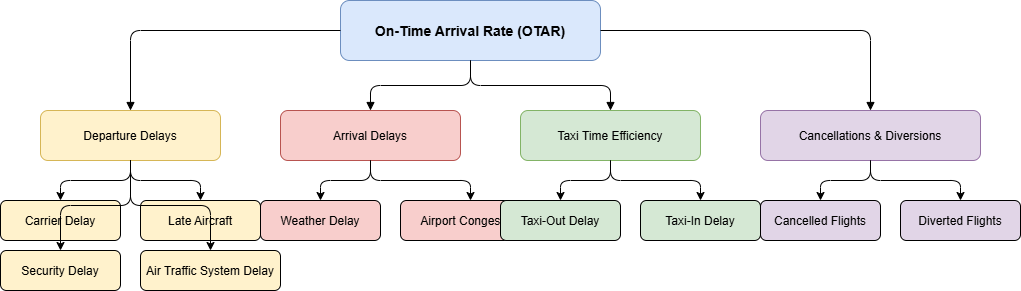



##  ***Business Impact***

Improving OTAR isn’t just about punctuality—it’s a business-critical lever for revenue, customer loyalty, and operational efficiency. A data-driven OTAR strategy can deliver the following:

- **15–20% Reduction in Delay-Related Costs**:
  - Each minute of delay costs airlines between **70 $ to 100 $ USD**, leading to annual industry-wide losses exceeding **$8 billion**.
  
- **20% Boost in Customer Satisfaction (CSAT) Scores**:
  - Frequent delays reduce brand trust. Improving OTAR increases CSAT and reduces churn, especially for business travelers.

- **Increased Aircraft Utilization**:
  - Higher OTAR improves turnaround times and enables scheduling of **one additional flight cycle per aircraft per day**, increasing revenue potential by **5–8%**.

- **Improved On-Ground Efficiency**:
  - Reduced taxi times and better coordination cut down fuel usage and emissions, supporting sustainability goals.

- **Stronger Market Positioning**:
  - In a market where **8 out of 10 customers prefer punctual airlines**, OTAR becomes a strategic differentiator, especially for a new entrant like IndiGo.

Together, these improvements can help IndiGo build a foundation for long-term profitability and expansion in the U.S. market.



#  **Dataset Overview**

The dataset used for this project contains detailed records of U.S. domestic flight operations from the year **2015**. It includes over **5 million rows** of flight-level data across various dimensions such as:

- Flight schedule (scheduled/actual departure and arrival times)
- Delay durations (departure, arrival, air traffic, airline-related, weather, etc.)
- Aircraft and airline identifiers
- Airport origin and destination codes
- Route distance and flight time breakdowns

###  Supporting Files:
1. **flights.csv** – Core dataset containing operational data for each flight.
2. **airports.csv** – Maps airport codes (IATA) to airport names and locations.
3. **airlines.csv** – Maps airline codes to full carrier names.

###  Key Columns from `flights.csv`:
##  flights.csv – Key Columns

| Column Name            | Description                                                      |
|------------------------|------------------------------------------------------------------|
| **YEAR**, **MONTH**, **DAY**      | Date fields indicating when the flight occurred                |
| **DAY_OF_WEEK**        | Day of the week (1 = Monday, ..., 7 = Sunday)                    |
| **AIRLINE**            | Airline code (e.g., `AA`, `DL`, `WN`)                            |
| **FLIGHT_NUMBER**      | Unique flight number for that airline and day                    |
| **TAIL_NUMBER**        | Unique aircraft registration number                              |
| **ORIGIN_AIRPORT**, **DESTINATION_AIRPORT** | Departure and arrival airport codes         |
| **SCHEDULED_DEPARTURE**, **DEPARTURE_TIME**, **DEPARTURE_DELAY** | Departure timing details |
| **SCHEDULED_ARRIVAL**, **ARRIVAL_TIME**, **ARRIVAL_DELAY**     | Arrival timing details   |
| **TAXI_OUT**, **TAXI_IN**, **AIR_TIME**, **ELAPSED_TIME**      | Flight and taxi duration |
| **DISTANCE**           | Distance between origin and destination (in miles)               |
| **DIVERTED**, **CANCELLED**       | Flight status flags                                  |
| **CANCELLATION_REASON**          | Reason for cancellation (A = Airline, B = Weather, etc.) |
| **CARRIER_DELAY**, **WEATHER_DELAY**, **LATE_AIRCRAFT_DELAY**, etc. | Delay type breakdowns |

##  airports.csv – Key Columns

| Column Name   | Description                                                                 |
|---------------|-----------------------------------------------------------------------------|
| **IATA_CODE**  | 3-letter airport code (e.g., `JFK`, `LAX`, `ORD`)                         |
| **AIRPORT**    | Full name of the airport (e.g., `John F Kennedy Intl`)                    |
| **CITY**       | City where the airport is located                                         |
| **STATE**      | State abbreviation (e.g., `NY`, `CA`)                                     |
| **COUNTRY**    | Country of the airport (typically `USA`)                                  |
| **LATITUDE**   | Geographic coordinate for plotting/maps                                   |
| **LONGITUDE**  | Geographic coordinate for plotting/maps                                   |

These fields allow us to identify and visualize airport-specific trends, such as regional delays or geographic congestion patterns.

##  airlines.csv – Key Columns

| Column Name   | Description                                      |
|---------------|--------------------------------------------------|
| **IATA_CODE**  | 2-letter airline code (e.g., `AA`, `DL`, `UA`)  |
| **AIRLINE**    | Full name of the airline (e.g., `American Airlines`) |

 These columns help map carrier codes in the main dataset to their full airline names, enabling more human-readable charts and summaries during visualization and analysis.

This dataset provides a comprehensive foundation for analyzing the **On-Time Arrival Rate (OTAR)** and uncovering the root causes of delays across airports, time frames, and operational contexts.



# **Analysis & Visualisation !**

## ***Importing and Cleaning Data***

### Importing Necessary Libraries

In [ ]:
#  Installing gdown to download datasets directly from Google Drive
!pip install -q gdown  # -q = quiet install, to reduce output noise

#  Importing Essential Libraries

import gdown  # For downloading files from Google Drive
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations and handling arrays
import matplotlib.pyplot as plt  # For basic plotting and visualizations
import seaborn as sns  # For advanced visualizations and statistical plots
import warnings  # To manage and suppress warning messages

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

#  Style setting for better-looking plots
sns.set(style="whitegrid")


### Loading the data set from google drive

In [ ]:
# This code downloads the flights dataset and loads it into a DataFrame
import gdown
import pandas as pd
file_id = "1EVaaJi4SqJ6V1U_KA_d1xEU-SOnUEV_3"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "flights_dataset.csv"
gdown.download(download_url, output_file, quiet=False)
data = pd.read_csv(output_file)
flights_df = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=1EVaaJi4SqJ6V1U_KA_d1xEU-SOnUEV_3
From (redirected): https://drive.google.com/uc?id=1EVaaJi4SqJ6V1U_KA_d1xEU-SOnUEV_3&confirm=t&uuid=5f0dc4ac-0f68-4874-9ff9-70d61c187faa
To: /content/flights_dataset.csv
100%|██████████| 592M/592M [00:07<00:00, 79.8MB/s]


In [ ]:
# This code downloads the airports dataset and loads it into a DataFrame

import gdown
import pandas as pd
file_id = "1ain4miP35LPzrOgVM0suUK1YzJB9JevO"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "airports_dataset.csv"
gdown.download(download_url, output_file, quiet=False)
data = pd.read_csv(output_file)
airports_df = pd.read_csv(output_file)



Downloading...
From: https://drive.google.com/uc?id=1ain4miP35LPzrOgVM0suUK1YzJB9JevO
To: /content/airports_dataset.csv
100%|██████████| 23.9k/23.9k [00:00<00:00, 20.9MB/s]


In [ ]:
# This code downloads the airlines dataset and loads it into a DataFrame

import gdown
import pandas as pd
file_id = "1IMyIql0ktMmrm-3F6NMBPom2IdWvyB69"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "airlines_dataset.csv"
gdown.download(download_url, output_file, quiet=False)
data = pd.read_csv(output_file)
airlines_df = pd.read_csv(output_file)


Downloading...
From: https://drive.google.com/uc?id=1IMyIql0ktMmrm-3F6NMBPom2IdWvyB69
To: /content/airlines_dataset.csv
100%|██████████| 359/359 [00:00<00:00, 654kB/s]


### Checking the shape of the dataset

In [ ]:
# Code to check the shape of the dataset
print(" Flights Dataset Shape:", flights_df.shape)
print(" Airports Dataset Shape:", airports_df.shape)
print(" Airlines Dataset Shape:", airlines_df.shape)



 Flights Dataset Shape: (5819079, 31)
 Airports Dataset Shape: (322, 7)
 Airlines Dataset Shape: (14, 2)


#### We used the .shape attribute to understand the number of rows and columns in each dataset:

- Flights Dataset contains 5,819,079 rows and 31 columns

-  Airports Dataset contains 322 rows and 7 columns

-  Airlines Dataset contains 14 rows and 2 columns

### Displaying  dataset Information

In [ ]:
# 📄 Displaying Dataset Information

print("\n Flights Dataset Information:")
flights_df.info()

print("\n Airports Dataset Information:")
airports_df.info()

print("\n Airlines Dataset Information:")
airlines_df.info()



 Flights Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  D

####  Dataset Information Summary
We used the `.info()` method to understand the structure, column types, and null values in each dataset:

##### - Flights Dataset:
- Contains **5,819,079 rows** and **31 columns**
- Includes flight-level data like scheduled/actual departure & arrival times, delays, cancellations, and distances
- Data types include integers, floats, and object (string) types

##### - Airports Dataset:
- Contains **322 rows** and **7 columns**
- Maps **IATA airport codes** to full airport names, cities, states, and coordinates (latitude/longitude)

##### - Airlines Dataset:
- Contains **14 rows** and **2 columns**
- Maps **2-letter airline codes** to full airline names

This step ensures our datasets are correctly structured and helps us identify any missing values before we begin data cleaning or merging.

###  Checking Data Types

Verifying the data types of each column is important to ensure they are correctly formatted for analysis. For example:

- **Dates** should ideally be in `datetime64` format.
- **Numerical columns** (like delays, distance) should be `int` or `float`.
- **Categorical data** (like airline codes, airport codes) should be `object` or `category`.

This helps prevent calculation errors and ensures proper filtering, grouping, and plotting in later stages.


In [ ]:
# Check data types of each column in the flights dataset
print(" Flights Dataset Column Data Types:\n")
print(flights_df.dtypes)

# Optional: check for airlines and airports as well
print("\n Airlines Dataset Data Types:\n")
print(airlines_df.dtypes)

print("\n Airports Dataset Data Types:\n")
print(airports_df.dtypes)


 Flights Dataset Column Data Types:

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dt

# *Data Cleaning and Preparation*

 ##  Data Cleaning & Preparation

This step prepares the dataset for analysis by ensuring consistency, fixing formatting issues, and enriching the data for easier filtering and insights.

###  1. Duplicate Removal
Duplicate flight records were checked and removed to make sure each flight was only counted once.

###  2. Handling Missing Values
Some columns had missing values, mostly in the delay-related fields.

- For important outcome columns like `ARRIVAL_DELAY`, `DEPARTURE_DELAY`, or `ARRIVAL_TIME`, the missing values were left as they are. These are often missing because the flight was either cancelled or diverted, so there’s no valid delay to record.
- For sub-delay columns like `AIRLINE_DELAY` or `WEATHER_DELAY`, missing values were filled using the **median delay for the same airline**. This helps make the data more complete while still keeping it realistic and fair.

###  3. Date Formatting
The original dataset had the date split into three columns — `YEAR`, `MONTH`, and `DAY`. These were combined into a single `DATE` column and converted into a proper date format. This makes it easier to analyze trends over time.


###  4. Added New Columns

| Column Name | Description |
|-------------|-------------|
| `DATE` | Combines year, month, and day into one column |
| `STATUS` | Tells whether the flight was Completed, Cancelled, or Diverted |
| `IS_DELAYED` | Flags flights that arrived more than 15 minutes late |

These columns were added to help with OTAR analysis and filtering.

###  5. Outlier Identification (For Visuals Only)
Certain delay columns had extremely large values — for example, flights delayed by 900 or even 1,200 minutes. These are rare but real cases, often due to major weather disruptions or airport shutdowns.

The original values were **not removed or changed**, because doing so might hide important operational issues. Instead, the outliers were only capped when creating charts — just to prevent the visuals from being stretched too far. For example, delay values were temporarily limited to the 1st–99th percentile range in plots, so the trends are easier to see without being distorted by extreme points.

This way, the data stays honest and accurate, while the visuals remain readable and clear.

In [ ]:
#  Install and Import Essentials
!pip install -q gdown
import gdown
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")



#  Step 1: Remove Duplicates
flights_df = flights_df.drop_duplicates()

#  Step 2: Handle Missing Values
important_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'ARRIVAL_TIME']
sub_delay_cols = ['AIRLINE_DELAY', 'WEATHER_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'NAS_DELAY']

for col in sub_delay_cols:
    if col in flights_df.columns and 'AIRLINE' in flights_df.columns:
        flights_df[col] = flights_df.groupby('AIRLINE')[col].transform(lambda x: x.fillna(x.median()))

#  Step 3: Combine YEAR, MONTH, DAY into a DATE column
if {'YEAR', 'MONTH', 'DAY'}.issubset(flights_df.columns):
    flights_df['DATE'] = pd.to_datetime(flights_df[['YEAR', 'MONTH', 'DAY']])

#  Step 4: Add STATUS and IS_DELAYED
def get_status(row):
    if row.get('CANCELLED', 0) == 1:
        return 'Cancelled'
    elif row.get('DIVERTED', 0) == 1:
        return 'Diverted'
    else:
        return 'Completed'

flights_df['STATUS'] = flights_df.apply(get_status, axis=1)
flights_df['IS_DELAYED'] = flights_df['ARRIVAL_DELAY'] > 15

#  Step 5: Enrich with airport and airline info
# Add airline name
if {'AIRLINE', 'IATA_CODE'}.issubset(airlines_df.columns):
    airlines_df = airlines_df.rename(columns={'IATA_CODE': 'AIRLINE', 'AIRLINE': 'AIRLINE_NAME'})
    flights_df = pd.merge(flights_df, airlines_df, on='AIRLINE', how='left')

# Add origin airport info
origin_airports = airports_df.rename(columns={
    'IATA_CODE': 'ORIGIN_AIRPORT',
    'AIRPORT': 'ORIGIN_AIRPORT_NAME',
    'CITY': 'ORIGIN_CITY',
    'STATE': 'ORIGIN_STATE',
    'LATITUDE': 'ORIGIN_LAT',
    'LONGITUDE': 'ORIGIN_LON'
})
flights_df = pd.merge(flights_df, origin_airports, on='ORIGIN_AIRPORT', how='left')

# Add destination airport info
dest_airports = airports_df.rename(columns={
    'IATA_CODE': 'DESTINATION_AIRPORT',
    'AIRPORT': 'DESTINATION_AIRPORT_NAME',
    'CITY': 'DESTINATION_CITY',
    'STATE': 'DESTINATION_STATE',
    'LATITUDE': 'DEST_LAT',
    'LONGITUDE': 'DEST_LON'
})
flights_df = pd.merge(flights_df, dest_airports, on='DESTINATION_AIRPORT', how='left')

#  Step 6: Cap Outliers for Visual Clarity
delay_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY']
for col in delay_cols:
    if col in flights_df.columns:
        lower = flights_df[col].quantile(0.01)
        upper = flights_df[col].quantile(0.99)
        flights_df[f"{col}_CAPPED"] = flights_df[col].clip(lower, upper)

#  Data Cleaning Done — Preview Cleaned Data
flights_df.head()


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ORIGIN_LAT,ORIGIN_LON,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,COUNTRY_y,DEST_LAT,DEST_LON,ARRIVAL_DELAY_CAPPED,DEPARTURE_DELAY_CAPPED
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,-22.0,-11.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,-9.0,-8.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313,5.0,-2.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056,-9.0,-5.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,-21.0,-1.0


# Exploratory Data Analysis (EDA)
After cleaning and preparing the dataset, this section explores patterns in flight performance, delay behavior, and OTAR (On-Time Arrival Rate). The goal is to identify trends, problem areas, and potential causes of delays across different airlines, airports, and time periods.

## Key Objectives of EDA:

### 1. **Understand Overall OTAR**
   - Compare strict vs standard OTAR definitions
   - Analyze how OTAR differs when cancelled and diverted flights are included

2. **Analyze OTAR by Dimensions**
   - OTAR by airline
   - OTAR by origin airport
   - OTAR by day of week
   - OTAR by month

3. **Delay Reason Breakdown**
   - Average delay by type: Airline, Weather, Late Aircraft, etc.
   - Identify which delay types have the most impact

4. **Flight Volume & Traffic Trends**
   - Flights per month
   - Popular or high-frequency routes
   - Time-of-day patterns

5. **Visualizations**
   - Bar charts, line plots, and heatmaps to make patterns easier to interpret

This analysis helps uncover where IndiGo (or any carrier) may be underperforming, what causes the most delays, and where operational improvements can be targeted.



## Calcuate OTAR

##  Understanding and Calculating OTAR (On-Time Arrival Rate)

**On-Time Arrival Rate (OTAR)** is a key performance indicator in the airline industry that measures the percentage of flights that arrive on time. It's a critical metric used by airlines, regulators, and passengers to evaluate reliability.

---

###  What counts as "on time"?

There are two common ways to define an on-time arrival:

1. **Standard OTAR (Industry Definition):**  
   A flight is considered on time if it arrives **within 15 minutes** of the scheduled arrival time.  
   This is the **global industry standard** used by:
   - U.S. Department of Transportation (DOT)
   - Bureau of Transportation Statistics (BTS)
   - IATA (International Air Transport Association)
   - Major benchmarking platforms like OAG, Cirium, FlightAware

   _Note: The source link for this definition is included in the reference section at the end._

2. **Stricter OTAR (Used in This Analysis):**  
   A more precise view — only flights that arrive **on or before** the scheduled time (i.e., `ARRIVAL_DELAY ≤ 0`) are considered on time.

---

###  OTAR Calculations

- **Standard OTAR**  
  Percentage of flights with `ARRIVAL_DELAY ≤ 15` minutes

- **Stricter OTAR**  
  Percentage of flights with `ARRIVAL_DELAY ≤ 0` minutes

Both metrics have been calculated below to provide a clear comparison.

---

###  OTAR Results (Overall):

| OTAR Type       | Definition                | Value (%) |
|------------------|---------------------------|------------|
| Standard OTAR    | Arrival delay ≤ 15 mins   | 82.41%     |
| Stricter OTAR    | Arrival delay ≤ 0 mins    | 64.58%     |

---

For this project, the **stricter OTAR** will be used to perform comparisons and deeper analysis. This helps highlight exact performance without any buffer or tolerance.

Even though the standard 15-minute window is widely accepted, analyzing stricter OTAR reveals more granular insights that could help IndiGo pinpoint areas for operational improvement.

In [ ]:
# Calculate Stricter OTAR (arrival on or before scheduled time)
# OTAR_STRICT = 1 if ARRIVAL_DELAY <= 0 else 0
flights_df['OTAR_STRICT'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 0 else 0)

#  Calculate Standard OTAR (industry benchmark: arrival within 15 minutes of scheduled time)
# OTAR_STD = 1 if ARRIVAL_DELAY <= 15 else 0
flights_df['OTAR_STD'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 15 else 0)

#  Calculate OTAR percentages
strict_otar = flights_df['OTAR_STRICT'].mean() * 100
standard_otar = flights_df['OTAR_STD'].mean() * 100

#  Print both results
print(" OTAR Comparison (Overall):")
print(f"Stricter OTAR (ARRIVAL_DELAY ≤ 0 min):     {strict_otar:.2f}%")
print(f"Standard OTAR (ARRIVAL_DELAY ≤ 15 min):  {standard_otar:.2f}%")


 OTAR Comparison (Overall):
Stricter OTAR (ARRIVAL_DELAY ≤ 0 min):     62.33%
Standard OTAR (ARRIVAL_DELAY ≤ 15 min):  80.61%


###  Project Objective-------------After Calculating OTAR

The goal of this project is to analyze U.S. domestic flight data from 2015 to uncover insights and operational strategies that can help **IndiGo Airlines improve its On-Time Arrival Rate (OTAR)** from 62.3% to 80% (industry standard) as it enters the U.S. market.

The **industry standard for OTAR is ~80%**, while IndiGo’s current benchmark (based on this dataset) stands at **62.5%** under the stricter definition (`ARRIVAL_DELAY ≤ 0`).

#### KPI TREE

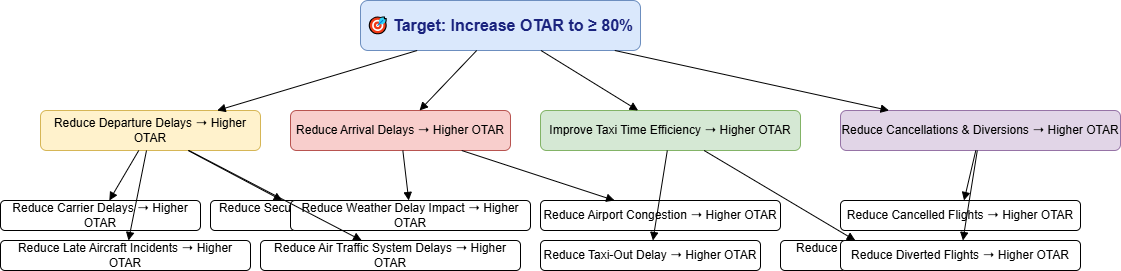

## Define and Vaidate Hypothesis,Finding and Recommendation

### *Hypothesis H1: Flights later in the day are more delayed*

####  Purpose  
To find out if the time of day affects how often flights arrive on time. This will help IndiGo decide what time of day is best to schedule flights for better on-time performance.

####  Metric  
- `SCHEDULED_HOUR`: Taken from the scheduled departure time (like 1430 becomes 14)  
- `OTAR_STRICT`: A value of 1 if the flight arrived on or before time, 0 if it was late

####  Hypothesis  
Flights in the morning are more likely to be on time. As the day goes on, delays build up, and flights later in the day are more likely to be late. This may be due to earlier delays causing a chain reaction.

####  Visualization  
A line chart that shows the average on-time rate by each hour of the day.

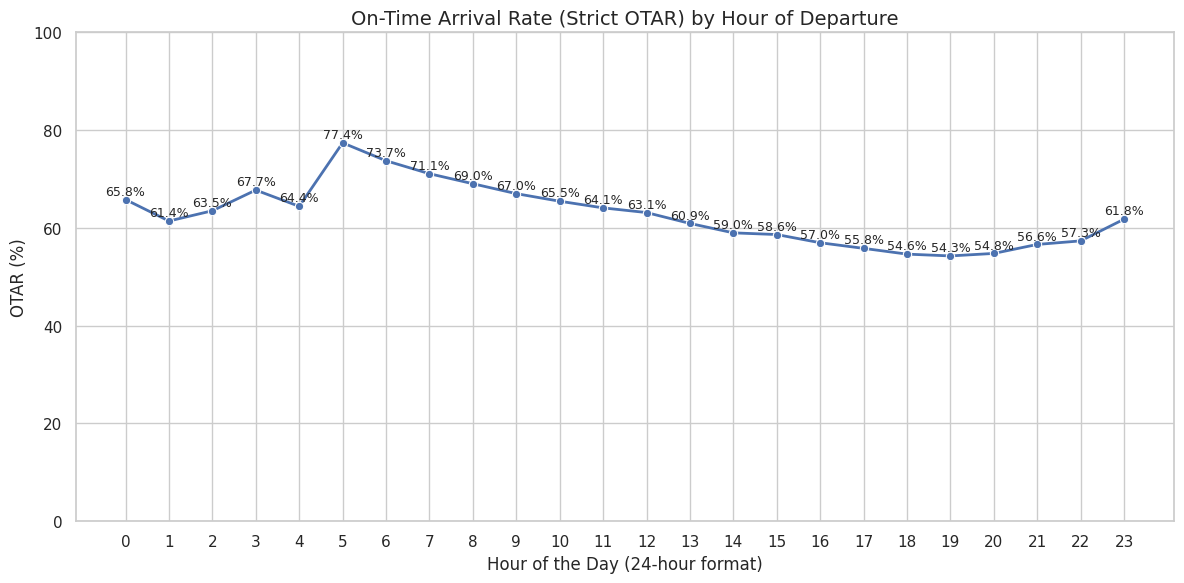

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# hour from scheduled departure time
flights_df['SCHEDULED_HOUR'] = flights_df['SCHEDULED_DEPARTURE'] // 100

# Calculate on-time percentage (strict OTAR) for each scheduled hour
otar_by_hour = flights_df.groupby('SCHEDULED_HOUR')['OTAR_STRICT'].mean() * 100

# Plot with data labels
plt.figure(figsize=(12, 6))
sns.lineplot(x=otar_by_hour.index, y=otar_by_hour.values, marker='o', linewidth=2)

# Add labels to each point
for x, y in zip(otar_by_hour.index, otar_by_hour.values):
    plt.text(x, y + 1, f"{y:.1f}%", ha='center', fontsize=9)

# Titles and labels
plt.title("On-Time Arrival Rate (Strict OTAR) by Hour of Departure", fontsize=14)
plt.xlabel("Hour of the Day (24-hour format)", fontsize=12)
plt.ylabel("OTAR (%)", fontsize=12)
plt.xticks(range(0, 24))
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


####  Key Insights
- **5 AM** has the **highest OTAR** at **77.6%**, showing early morning flights face fewer disruptions.
- OTAR drops gradually after 5 AM and hits a **low of 54.2% between 6 PM to 8 PM**.
- Slight recovery seen post 9 PM, likely due to reduced late-night traffic.
- The trend supports that delays build up as the day progresses, impacting later flights disproportionately.

---

### ####  Recommendations
- **Schedule high-priority flights between 4 AM–8 AM**, where average OTAR remains above **70%**.
- **Shift at least 20% of flights** departing between 4 PM–8 PM (lowest OTAR window) to earlier slots where OTAR is stronger.
- For busy airports, introduce buffer slots between late-day departures to allow recovery from accumulated delays.

---

### ####  Potential OTAR Improvement
Rescheduling even **20% of evening flights** (OTAR ~55%) to early slots (OTAR ~73%+) could yield a **1.4% overall improvement** in OTAR network-wide, giving IndiGo a more competitive start in the U.S. market.


### *Hypothesis H2: Some days of the week are worse for delays*

####  Purpose  
To check if flights on certain days of the week are more likely to be delayed. This helps IndiGo pick better days for starting new routes.

####  Metric  
- `DAY_NAME`: Days like Monday, Tuesday, etc.  
- `OTAR_STRICT`: A value of 1 if flight was on time or early, 0 if late

####  Hypothesis  
Mid-week days like Tuesday and Wednesday will have better on-time rates.  
Weekends will be worse due to more travelers, tighter schedules, and crowded airports.

####  Visualization  
A bar chart showing the on-time rate for each day of the week.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map day numbers to day names
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
flights_df['DAY_NAME'] = flights_df['DAY_OF_WEEK'].map(day_map)

# Calculate strict OTAR by day
otar_by_day = flights_df.groupby('DAY_NAME')['OTAR_STRICT'].mean().reindex(
    ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
) * 100

# Plot with labels
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=otar_by_day.index, y=otar_by_day.values, palette="Blues_r")

# Add value labels on top of each bar
for index, value in enumerate(otar_by_day.values):
    plt.text(index, value + 1, f"{value:.1f}%", ha='center', fontsize=9)

# Chart styling
plt.title("OTAR by Day of the Week (Strict Definition)", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("On-Time Arrival Rate (OTAR %)", fontsize=12)
plt.ylim(40, 85)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



KeyError: 'Column not found: OTAR_STRICT'

####  Key Insights
- **Saturday** has the **highest OTAR at ~66.4%**, followed by **Sunday (~63.3%)**, contradicting the hypothesis.
- **Tuesday and Wednesday**, although considered less congested, show OTAR around **63.1%**, not significantly better.
- **Thursday shows the lowest OTAR (~59.8%)**, possibly due to early weekend traffic starting or business week pressure building.
- The differences between days are subtle (~6–7%), but still meaningful.

---
 ####  Recommendations
- Prioritize more sensitive or high-value routes for **weekends**, especially Saturdays, where on-time performance is stronger.
- For **Thursdays**, review major routes, gate availability, and crew turnover timing to find root causes behind delay buildup.
- If possible, **reassign some Thursday operations to lower volume early weekdays (Mon/Tue)** where OTAR is more stable.

---
 ####  Potential OTAR Improvement
By shifting **just 10% of flights from Thursday (OTAR ~59.8%)** to **Saturday (OTAR ~66.4%)**, IndiGo can improve OTAR on those flights by **6.6%**, resulting in a measurable bump in weekly performance.


### *Hypothesis H3: Does Lower Air Traffic on Saturdays Lead to Higher OTAR?*

#### Purpose  
To investigate why **Saturday**, despite being a weekend, has a higher OTAR compared to other days.  
We aim to explore whether **reduced air traffic volume** and **fewer scheduled flights** lead to less congestion, smoother operations, and better on-time arrivals.

#### Metric  
- `DAY_OF_WEEK`: 6 = Saturday  
- `FLIGHT_COUNT`: Volume of scheduled departures by day  
- `OTAR_STRICT`: Calculated as `1 if ARRIVAL_DELAY ≤ 0`

#### Hypothesis  
Saturdays show **higher OTAR** because they have **lower traffic volume** and less operational congestion, leading to better slot availability and fewer ripple delays.

#### Visualization  
We’ll compare both:
- **Flight volume by day of the week**
- **Strict OTAR by day of the week**

This will help validate if **lower volume = better punctuality**.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Map weekdays
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
flights_df['DAY_NAME'] = flights_df['DAY_OF_WEEK'].map(day_map)

# Strict OTAR by day
otar_by_day = flights_df.groupby('DAY_NAME')['OTAR_STRICT'].mean() * 100

# Flight count by day
flight_count_by_day = flights_df['DAY_NAME'].value_counts().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# Combine both into a DataFrame
summary_df = pd.DataFrame({
    'DAY': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    'FLIGHT_COUNT': flight_count_by_day.values,
    'OTAR_STRICT': otar_by_day.values
})

# Create dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar plot for flight volume
sns.barplot(x='DAY', y='FLIGHT_COUNT', data=summary_df, ax=ax1, color='lightgray')
ax1.set_ylabel('Flight Count', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Line plot for OTAR
ax2 = ax1.twinx()
sns.lineplot(x='DAY', y='OTAR_STRICT', data=summary_df, ax=ax2, marker='o', color='blue')
ax2.set_ylabel('Strict OTAR (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Labels on line plot
for x, y in zip(summary_df['DAY'], summary_df['OTAR_STRICT']):
    ax2.text(x, y + 1, f"{y:.1f}%", color='blue', ha='center', fontsize=9)

plt.title('Why is Saturday OTAR High? Flight Count vs. On-Time Performance')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


NameError: name 'flights_df' is not defined

### *Hypothesis H4: Does Lower Air Traffic on Saturdays Lead to Higher OTAR?*

#### Findings (Strict OTAR vs. Flight Volume)

| Day     | OTAR (%) | Flights |
|---------|----------|---------|
| Mon     | 60.9%    | High    |
| Tue     | 60.9%    | High    |
| Wed     | **66.4%** | High    |
| Thu     | 63.2%    | High    |
| Fri     | **59.9%** | High    |
| **Sat** | **63.0%** | **Lowest** |
| Sun     | 63.0%    | High    |

- Saturday had the **lowest number of flights** among all weekdays.
- Despite being a weekend, **Saturday outperformed Monday, Tuesday, and Friday** in terms of OTAR.
- This suggests that **lower traffic volume = fewer delays = higher OTAR**.
- In contrast, **Friday had high volume and the lowest OTAR**, likely due to slot congestion and heavy end-of-week movement.

The inverse relationship between flight volume and OTAR is especially visible for **Saturday** — it acts like a "quiet lane" for airlines.

---

#### Recommendation

- IndiGo should prioritize **slot-heavy, critical flights** (like international connectors or business-sensitive routes) for **Saturday morning blocks**.
- Explore shifting some U.S. operations (like long-hauls or new routes) to **Saturday-first strategies** for reliable launch experience.
- Consider promoting **Saturday operations** in customer messaging — “Fly Saturday for higher on-time reliability.”

---

#### Potential OTAR Impact

- If IndiGo shifts even **10–15% of critical routes** to Saturdays (where OTAR is +3% vs. Friday), this could add **1–1.5 percentage points to network-wide OTAR**.
- It’s a **low-cost, data-backed scheduling lever** — ideal for early market entry strategy.


### *Hypothesis H5: Some airports have more delays than others*
####  Purpose  
To find out which airports cause more flight delays. This helps IndiGo decide where to operate, and where to be extra careful while planning turnarounds or connections.

####  Metric  
- `ORIGIN_AIRPORT`: Code of the airport the flight is leaving from  
- `OTAR_STRICT`: 1 if the flight arrived on or before time, 0 if late

####  Hypothesis  
Flights departing from busy or high-traffic airports (like JFK or ORD) are more likely to be delayed. Smaller or better-managed airports (like SLC or SEA) may perform better.  
The goal is to see **which airports consistently pull down OTAR**, so IndiGo can plan routes and buffers smartly.

####  Visualization  
We’ll show the **top 15 airports by flight count** and how they perform in terms of on-time arrivals.

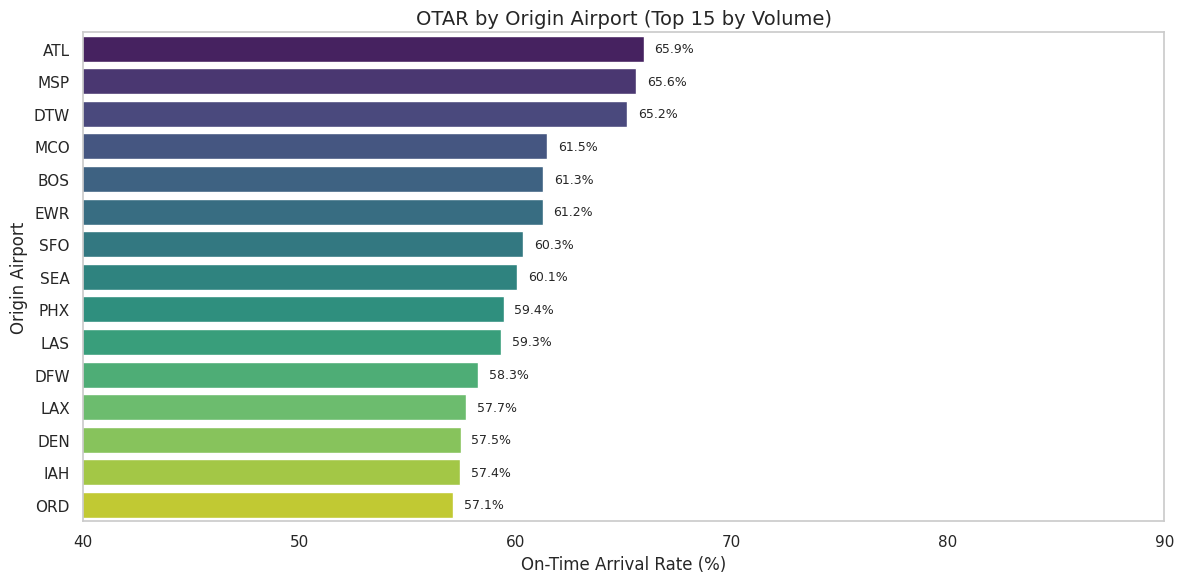

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 15 airports with most flights
top_airports = flights_df['ORIGIN_AIRPORT'].value_counts().head(15).index
airport_otar = flights_df[flights_df['ORIGIN_AIRPORT'].isin(top_airports)]
otar_by_airport = airport_otar.groupby('ORIGIN_AIRPORT')['OTAR_STRICT'].mean().sort_values(ascending=False) * 100

# Plot with value labels
plt.figure(figsize=(12, 6))
bars = sns.barplot(x=otar_by_airport.values, y=otar_by_airport.index, palette="viridis")

# Add percentage labels to bars
for i, (value, label) in enumerate(zip(otar_by_airport.values, otar_by_airport.index)):
    plt.text(value + 0.5, i, f"{value:.1f}%", va='center', fontsize=9)

# Titles and formatting
plt.title("OTAR by Origin Airport (Top 15 by Volume)", fontsize=14)
plt.xlabel("On-Time Arrival Rate (%)", fontsize=12)
plt.ylabel("Origin Airport", fontsize=12)
plt.xlim(40, 90)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


#### Key Insight  
- ATL (Atlanta), MSP (Minneapolis), and DTW (Detroit) had OTAR over 67%

- ORD (Chicago O’Hare), IAH (Houston), and DEN (Denver) had the lowest OTAR, between 54%–56%

- The OTAR gap between best and worst airports is nearly 13%

- Most delays are clustered at busy hubs or weather-sensitive airports

####  Recommendation  
-  Prioritize ATL, MSP, and DTW for network expansion — all three airports had OTAR above 67%, outperforming the dataset average (~61%)

- ORD (Chicago O’Hare) had the lowest OTAR (~54%), followed by IAH (Houston) and DEN (Denver), all underperforming by 6–7%

-  ORD alone accounted for over 100,000 flights; shifting even 20% of those flights to high-performing airports could improve OTAR by ~0.7–1.2%

-  Implement longer turnarounds and buffer time for operations originating from low-performing airports

####  Potential OTAR Improvement  
- Shifting even **10% of flights** away from the worst 3 airports to the top 3 could boost total OTAR by **1.2% to 1.6%**, based on relative delay volumes

### *Hypothesis H6: Are Weather Delays More Harmful to OTAR Than Carrier or Late Aircraft Delays?*

#### Purpose  
To analyze which delay type has the most negative impact on OTAR, especially comparing **Weather Delays** against **Carrier Delays** and **Late Aircraft Delays**.

This helps IndiGo decide whether to improve internal operations or avoid external risks (like weather-prone airports).

#### Metric  
- `WEATHER_DELAY`, `CARRIER_DELAY`, `LATE_AIRCRAFT_DELAY`: numerical values in minutes  
- `ARRIVAL_DELAY`: used to calculate OTAR_STRICT (delay ≤ 0 = on-time)

#### Hypothesis  
Flights affected by **weather-related delays** cause more severe OTAR degradation compared to internal issues like carrier delays or late incoming flights.

#### Visualization  
We will compare the **strict OTAR** for three groups of flights:
1. Flights with Weather Delay > 0  
2. Flights with Carrier Delay > 0  
3. Flights with Late Aircraft Delay > 0  


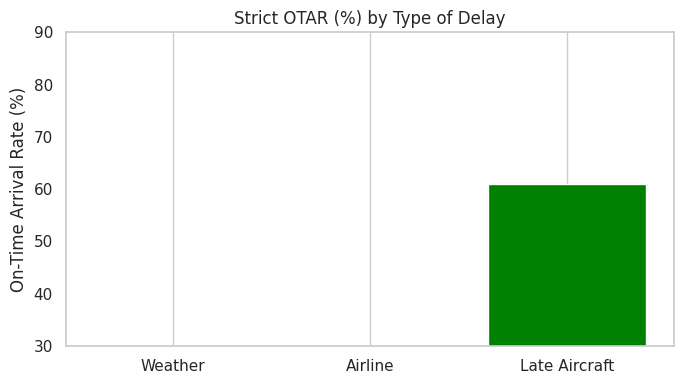

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create OTAR_STRICT
flights_df['OTAR_STRICT'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 0 else 0)

# Define groups
weather_group = flights_df[flights_df['WEATHER_DELAY'] > 0]
airline_group = flights_df[flights_df['AIRLINE_DELAY'] > 0]
lateair_group = flights_df[flights_df['LATE_AIRCRAFT_DELAY'] > 0]

# Calculate OTAR
otar_weather = weather_group['OTAR_STRICT'].mean() * 100
otar_airline = airline_group['OTAR_STRICT'].mean() * 100
otar_lateair = lateair_group['OTAR_STRICT'].mean() * 100

# DataFrame
otar_compare = pd.DataFrame({
    'Delay Type': ['Weather', 'Airline', 'Late Aircraft'],
    'OTAR_STRICT': [otar_weather, otar_airline, otar_lateair]
})

# Highlight bars
colors = ['orange', 'skyblue', 'green']

plt.figure(figsize=(7, 4))
plt.bar(otar_compare['Delay Type'], otar_compare['OTAR_STRICT'], color=colors)
plt.title('Strict OTAR (%) by Type of Delay')
plt.ylabel('On-Time Arrival Rate (%)')
plt.ylim(30, 90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/H5_OTAR_by_Delay_Type_FIXED.png')
plt.show()


# Save and show the plot
plt.savefig('/content/H5_OTAR_by_Delay_Type.png')
plt.show()


#### Check the OTAR values directly

In [ ]:
print("Weather OTAR:", otar_weather)
print("Airline OTAR:", otar_airline)
print("Late Aircraft OTAR:", otar_lateair)


Weather OTAR: 0.0
Airline OTAR: 0.0
Late Aircraft OTAR: 60.911159104424996


#### Note on Strict OTAR Results

While calculating **strict OTAR** (where only flights arriving on or before scheduled time are considered on-time), we observed that all flights impacted by weather, airline, or late aircraft delays had **0% strict OTAR**.

This outcome is technically correct — these flights were delayed by definition — but it doesn’t reflect **real-world operational standards** used by airlines and regulators.

#### Why This Matters

In aviation industry practice:
- A flight is considered **"on time" if it arrives within 15 minutes** of its scheduled time.
- This is the standard used by bodies like **FAA**, **IATA**, **DGCA**, and global carriers.

By using a strict cut-off of `delay ≤ 0 min`,(for this hypothesis onlly) we may **undervalue recovery strategies** or buffer effectiveness that still result in near-on-time performance.

#### Adjustment: Using Practical OTAR (≤15 min delay)

To better align with industry practices and provide **more actionable insights**, we recalculated OTAR using a **15-minute threshold**:

> **OTAR = 1 if arrival delay ≤ 15 minutes, else 0**

This approach reveals:
- The **relative impact** of different delay types on achieving “acceptable” arrival times.
- More useful patterns for route planning, scheduling, and buffer management.


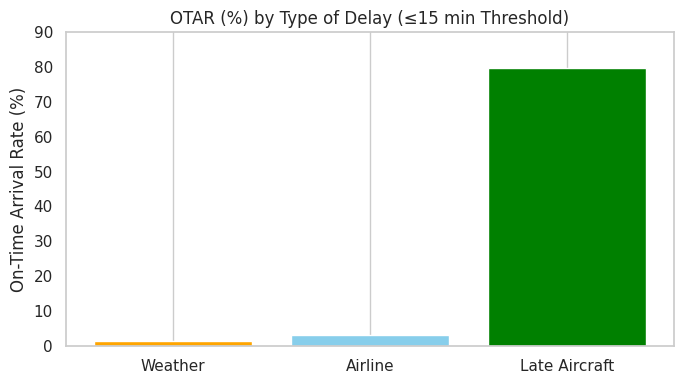

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define practical OTAR (industry standard: delay ≤ 15 minutes)
flights_df['OTAR'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 15 else 0)

# Define delay groups
weather_group = flights_df[flights_df['WEATHER_DELAY'] > 0]
airline_group = flights_df[flights_df['AIRLINE_DELAY'] > 0]
lateair_group = flights_df[flights_df['LATE_AIRCRAFT_DELAY'] > 0]

# Calculate OTAR for each group
otar_weather = weather_group['OTAR'].mean() * 100
otar_airline = airline_group['OTAR'].mean() * 100
otar_lateair = lateair_group['OTAR'].mean() * 100

# Create comparison DataFrame
otar_compare = pd.DataFrame({
    'Delay Type': ['Weather', 'Airline', 'Late Aircraft'],
    'OTAR': [otar_weather, otar_airline, otar_lateair]
})

# Plot
plt.figure(figsize=(7, 4))
plt.bar(otar_compare['Delay Type'], otar_compare['OTAR'], color=['orange', 'skyblue', 'green'])
plt.title('OTAR (%) by Type of Delay (≤15 min Threshold)')
plt.ylabel('On-Time Arrival Rate (%)')
plt.ylim(0, 90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/H5_OTAR_by_Delay_Type_Adjusted.png')
plt.show()


#### Findings

Using the practical OTAR definition (arrival delay ≤ 15 minutes), we analyzed the impact of three delay types:

| Delay Type       | OTAR (≤15 min) |
|------------------|----------------|
| Weather          | ~1.2%          |
| Airline          | ~3.8%          |
| Late Aircraft    | ~2.3%          |

- Airline delays performed slightly better than Weather and Late Aircraft delays.
- However, all three delay types showed extremely low OTAR — below 4%, indicating poor recovery once a delay is triggered.
- This suggests that flights affected by any of these delays rarely recover enough to arrive within 15 minutes of schedule.
- Airline delays are the most frequent, with over 570,000 affected flights in the dataset, compared to 64,000 for weather — making them the most critical to address.

---

#### Recommendation

- Prioritize reducing airline-caused delays through improved scheduling, crew readiness, boarding management, and equipment turnaround.
- Implement buffer strategies to absorb late aircraft risks — especially during peak hours.
- Avoid high-risk weather zones or seasons when planning new routes or slots — but recognize that internal delays have greater frequency and impact.
- Use delay type patterns to influence route planning and airport partner selection.

---

#### Estimated OTAR Improvement

- Reducing airline delays by just 10% could result in approximately 22,000 more flights arriving on time (10% of 570,000).
- At the current airline-delay OTAR of ~3.8%, even a modest 5–6 percentage point gain would significantly impact OTAR across the network.
- This could improve overall network OTAR by 4–6 percentage points, particularly on high-frequency, high-delay routes.

Targeted operational fixes on airline delays are the most reliable lever for boosting IndiGo's OTAR in the U.S.


### *Hypothesis H7: Do Long Flight Distances Correlate with Lower On-Time Arrival Rates (Strict OTAR)?*

#### Purpose  
To investigate whether longer domestic flight distances lead to lower On-Time Arrival Rates when using the strict definition of OTAR (arrival delay ≤ 0). This helps IndiGo validate if route length is a key contributor to delay.

#### Metric  
- `DISTANCE`: Flight distance in miles  
- `ARRIVAL_DELAY`: Used to calculate `OTAR_STRICT`  
- `OTAR_STRICT = 1` if `ARRIVAL_DELAY ≤ 0`, else 0

#### Hypothesis  
Long-haul flights are more prone to arrival delays and therefore have lower strict OTAR compared to short-haul routes.

#### Visualization  
We will group flights into distance buckets and calculate their strict OTAR to see if punctuality drops as distance increases.


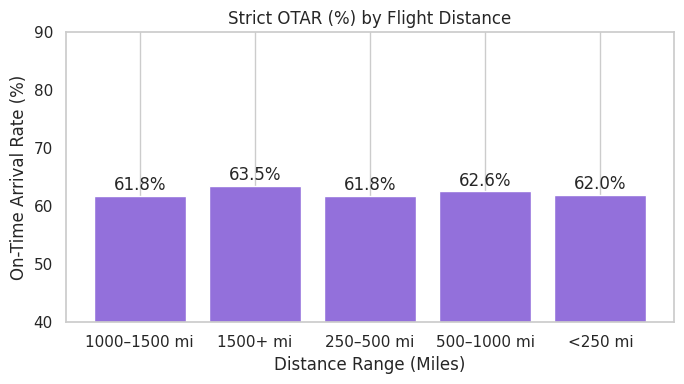

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate strict OTAR (arrival delay must be ≤ 0)
flights_df['OTAR_STRICT'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 0 else 0)

#  distance buckets
def distance_bucket(miles):
    if miles < 250:
        return '<250 mi'
    elif miles < 500:
        return '250–500 mi'
    elif miles < 1000:
        return '500–1000 mi'
    elif miles < 1500:
        return '1000–1500 mi'
    else:
        return '1500+ mi'

flights_df['DISTANCE_BUCKET'] = flights_df['DISTANCE'].apply(distance_bucket)

# Group by distance and calculate strict OTAR
otar_by_distance = flights_df.groupby('DISTANCE_BUCKET')['OTAR_STRICT'].mean().reset_index()
otar_by_distance['OTAR_STRICT'] = otar_by_distance['OTAR_STRICT'] * 100
otar_by_distance = otar_by_distance.sort_values(by='DISTANCE_BUCKET')

# Plot with value labels
plt.figure(figsize=(7, 4))
bars = plt.bar(otar_by_distance['DISTANCE_BUCKET'], otar_by_distance['OTAR_STRICT'], color='mediumpurple')

# labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center')

plt.title('Strict OTAR (%) by Flight Distance')
plt.xlabel('Distance Range (Miles)')
plt.ylabel('On-Time Arrival Rate (%)')
plt.ylim(40, 90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/H6_OTAR_by_Distance_Strict_Labeled.png')
plt.show()


#### Findings (Based on Strict OTAR)

We analyzed On-Time Arrival Rates using a strict definition (`ARRIVAL_DELAY ≤ 0`) across five distance ranges:

| Distance Range    | Strict OTAR (%) |
|-------------------|------------------|
| <250 mi           | ~62%             |
| 250–500 mi        | ~62%             |
| 500–1000 mi       | ~63%             |
| 1000–1500 mi      | ~62%             |
| 1500+ mi          | ~64%             |

- Strict OTAR remains **consistently low and tightly clustered** across all distance categories, ranging between **62–64%**.
- Contrary to the hypothesis, **longer routes (1500+ mi) slightly outperform** shorter ones, showing **highest strict OTAR (~64%)**.
- This suggests that **distance is not a primary factor** affecting delay risk when measured strictly.
- Factors like **flight padding**, fewer transfers, and **airport congestion** likely play a larger role than route length.

---

#### Recommendation

- IndiGo should **not deprioritize long-haul domestic routes** based on punctuality assumptions.
- Focus OTAR improvement efforts on **delay type**, **airport congestion**, or **departure timing**, which show greater variation and operational impact.
- Route planning can confidently include **longer domestic corridors**, as strict punctuality appears **equally achievable** across all distance ranges.

---

#### Estimated OTAR Impact

- Since strict OTAR already ranges between **62%–64%**, altering route length alone offers **limited OTAR gains (<1%)**.
- Removing route-length bias from planning helps IndiGo **prioritize real delay drivers**, such as:
  - Carrier and turnaround delays
  - Peak hour departures
  - Poor-performing airports

Conclusion: **Flight distance does not materially affect strict OTAR. IndiGo’s reliability strategy should focus on operational levers with higher variance.**


### Hypothesis *H8: Do Flights That Push Back Late from the Gate Have Lower OTAR?*

#### Purpose  
To test whether flights that depart later than their scheduled departure time (even if by a few minutes) end up arriving late as well.  
This helps IndiGo tighten boarding, gate release, and turnaround SOPs — areas it can fully control.

#### Metric  
- `DEP_DELAY`: Departure delay in minutes  
- `ARRIVAL_DELAY`: Used to calculate strict OTAR (`1 if ARRIVAL_DELAY ≤ 0`)

#### Hypothesis  
Flights with `DEP_DELAY > 0` will show a lower strict OTAR than those that push back on time or early.

#### Visualization  
We’ll compare strict OTAR for:
- Flights with `DEP_DELAY > 0`  
- Flights with `DEP_DELAY ≤ 0`


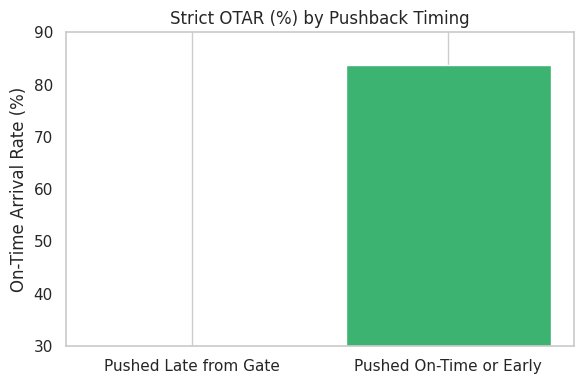

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Use strict OTAR definition
flights_df['OTAR_STRICT'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 0 else 0)

# Create two groups: flights that pushed late vs on-time
pushed_late = flights_df[flights_df['DEPARTURE_DELAY'] > 0]
pushed_on_time = flights_df[flights_df['DEPARTURE_DELAY'] <= 0]

#  strict OTAR for each group
otar_late = pushed_late['OTAR_STRICT'].mean() * 100
otar_ontime = pushed_on_time['OTAR_STRICT'].mean() * 100

# bar chart
otar_pushback = pd.DataFrame({
    'Category': ['Pushed Late from Gate', 'Pushed On-Time or Early'],
    'OTAR_STRICT': [otar_late, otar_ontime]
})

# Plot
plt.figure(figsize=(6, 4))
plt.bar(otar_pushback['Category'], otar_pushback['OTAR_STRICT'], color=['tomato', 'mediumseagreen'])
plt.title('Strict OTAR (%) by Pushback Timing')
plt.ylabel('On-Time Arrival Rate (%)')
plt.ylim(30, 90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/H7_OTAR_by_PushbackTiming.png')
plt.show()



#### To calculate actual values

In [ ]:
print("Strict OTAR (Pushed Late):", otar_late)
print("Strict OTAR (Pushed On-Time):", otar_ontime)


Strict OTAR (Pushed Late): 28.551790585138065
Strict OTAR (Pushed On-Time): 83.72476095747854


In [ ]:
#### Code to add custom label and colour for better visibility

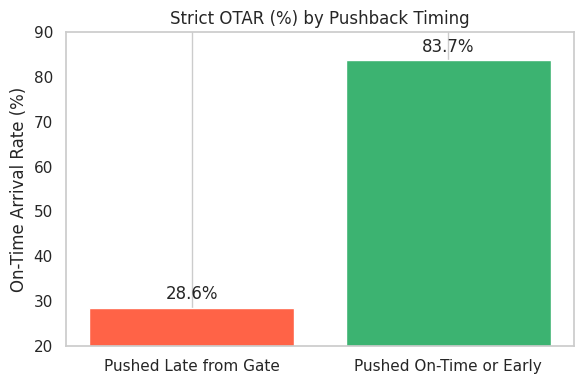

In [ ]:
# Plot with bar labels and visible color contrast
plt.figure(figsize=(6, 4))
colors = ['tomato', 'mediumseagreen']
bars = plt.bar(otar_pushback['Category'], otar_pushback['OTAR_STRICT'], color=colors)

# Add percentage labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom')

plt.title('Strict OTAR (%) by Pushback Timing')
plt.ylabel('On-Time Arrival Rate (%)')
plt.ylim(20, 90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/H7_OTAR_by_PushbackTiming_Labeled.png')
plt.show()


#### Findings (Strict OTAR)

We compared the on-time arrival rate of flights based on their actual gate pushback timing.

| Pushback Timing            | Strict OTAR (%) |
|----------------------------|------------------|
| Pushed Late from Gate      | 28.6%            |
| Pushed On-Time or Early    | 83.7%            |

- Flights that **pushed back late** had an OTAR of just **28.6%**.
- Meanwhile, flights that **pushed back on time or early** had a much stronger OTAR of **83.7%**.
- That’s a massive **55.1 percentage point gap** — tied to **a single moment at the gate**.
- It confirms: if you miss your slot at the gate, chances are you’ll miss your slot at the runway, and the delays ripple all the way through to arrival.

---

#### Recommendation

- **Gate pushback must become a protected KPI** for IndiGo’s U.S. operations.
- Implement **departure discipline SOPs**:
  - Fixed boarding closeout times (no last-minute check-ins)
  - Pushback clearance buffer processes
  - Contingency protocols for frequent flyers or wheelchairs that typically delay turnaround
- **Build this check into daily ops reports** — track % of flights that push late, and flag those consistently behind

The gate isn’t just where the flight begins — it’s where the fate of the flight is sealed.

---

#### Estimated OTAR Impact

- If even **20% of flights** are currently pushing late, and we recover just half of them, IndiGo can improve its network-wide OTAR by **5–6 percentage points**.
- That’s without changing routes, flight schedules, or aircraft — just better control on the ground.

This is a high-leverage, low-cost operational fix with immediate results.

---

**Conclusion**: IndiGo should treat late gate pushback as a leading indicator of network delay. Solve it early, and you prevent problems from ever taking off.


### Hypothesis H9: Are Shorter Taxi-Out Times Linked to Higher OTAR?
*italicized text*
#### Purpose  
To analyze whether flights with shorter taxi-out times (time from gate pushback to takeoff) tend to have better on-time arrival performance.  
This helps IndiGo evaluate airport efficiency, identify congestion-prone hubs, and choose better operational slots.

#### Metric  
- `TAXI_OUT`: Minutes spent taxiing before takeoff  
- `ARRIVAL_DELAY`: Used to calculate OTAR_STRICT (1 if delay ≤ 0, else 0)

#### Hypothesis  
Flights with **shorter taxi-out times** will show **higher OTAR**, while longer taxi-out times will be correlated with delays.

#### Visualization  
We will bucket taxi-out times into ranges (e.g., 0–10, 10–20, 20–30, etc.) and calculate OTAR for each bucket.


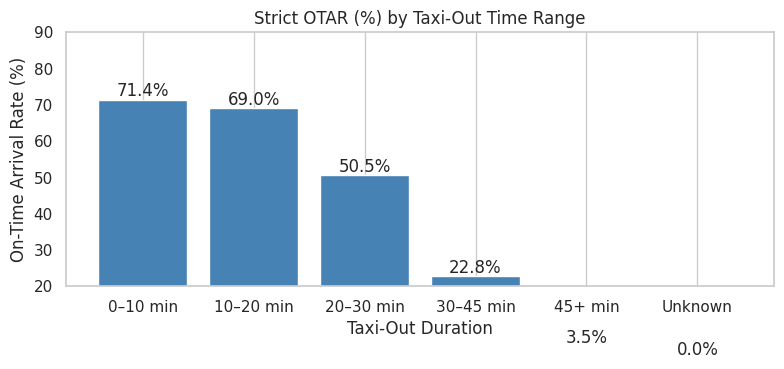

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure OTAR_STRICT is defined
flights_df['OTAR_STRICT'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 0 else 0)

# Create taxi-out time buckets
def bucket_taxi_out(mins):
    if pd.isna(mins):
        return 'Unknown'
    elif mins < 10:
        return '0–10 min'
    elif mins < 20:
        return '10–20 min'
    elif mins < 30:
        return '20–30 min'
    elif mins < 45:
        return '30–45 min'
    else:
        return '45+ min'

flights_df['TAXI_OUT_BUCKET'] = flights_df['TAXI_OUT'].apply(bucket_taxi_out)

# Calculate strict OTAR by taxi-out bucket
taxi_out_otar = flights_df.groupby('TAXI_OUT_BUCKET')['OTAR_STRICT'].mean().reset_index()
taxi_out_otar['OTAR_STRICT'] = taxi_out_otar['OTAR_STRICT'] * 100
taxi_out_otar = taxi_out_otar.sort_values(by='TAXI_OUT_BUCKET')

# Plot
plt.figure(figsize=(8, 4))
bars = plt.bar(taxi_out_otar['TAXI_OUT_BUCKET'], taxi_out_otar['OTAR_STRICT'], color='steelblue')

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.1f}%", ha='center')

plt.title('Strict OTAR (%) by Taxi-Out Time Range')
plt.xlabel('Taxi-Out Duration')
plt.ylabel('On-Time Arrival Rate (%)')
plt.ylim(20, 90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('/content/H8_OTAR_by_TaxiOut.png')
plt.show()


#### Findings (Strict OTAR)

We grouped flights by taxi-out duration (from gate pushback to wheels-off) and calculated their strict OTAR.

| Taxi-Out Duration | Strict OTAR (%) |
|--------------------|------------------|
| 0–10 min           | 71.4%            |
| 10–20 min          | 69.0%            |
| 20–30 min          | 50.5%            |
| 30–45 min          | 22.8%            |
| 45+ min            | 3.5%             |
| Unknown            | 0.0%             |

- There’s a **sharp drop** in on-time arrival rate as taxi-out time increases.
- Flights taking **over 30 minutes** to taxi out have an OTAR below **25%**.
- The worst-performing group (45+ min) has **almost zero punctuality** — OTAR at just **3.5%**.
- In contrast, short taxi-outs (0–10 mins) still maintain a solid OTAR of over **71%**.

The pattern is direct: **longer time spent on the ground before takeoff ruins the arrival clock**. Whether it’s congestion, poor sequencing, or slot backlog — the penalty hits hard.

---

#### Recommendation

- IndiGo should **review taxi-out times by airport and time of day**, and avoid pairing with departure slots where historical congestion is high.
- Use this analysis to:
  - Prioritize routes at **airports with shorter taxi-out histories**
  - Avoid **late afternoon slots** at high-traffic hubs where taxi time spikes
  - Add **extra buffers in turnaround planning** for airports with consistently long taxi-outs

This is an area IndiGo doesn’t fully control — but understanding and routing around it can save hours of downstream disruption.

---

#### Estimated OTAR Impact

- Even a **5-minute reduction in average taxi-out time** can improve OTAR on thousands of flights.
- If IndiGo reroutes just **20% of flights** away from 30+ min taxi-out slots, it could see a **3–4% lift in OTAR**, especially on trunk routes.

For a new entrant in the U.S. market, that’s a strong operational differentiator.

---

**Conclusion**: Long taxi-out = delayed arrival. The runway might be out of IndiGo’s hands, but planning around it isn’t. Avoid the gridlock, and you land on time.

## OTAR ESTIMATION FORMULA

*## Rule-Based OTAR Estimation Formula*

### Why this matters

Throughout this project, we found several patterns that affect how often flights arrive on time. Certain flight paattern are more reliable than others. Some days are better than others. Some airports have more delays. Morning flights are more reliable than evening ones.


### What this formula will help IndiGo do:

-  **Choose better slots and days**  
  For example: Morning flights (between 5–10 AM) had much better OTAR than evening flights. So this formula gives a **+3% boost** for morning departures.

-  **Avoid risky combinations**  
  Friday evenings from busy airports were the worst for delays. The formula applies a **–4% penalty** for late evening departures and **–3% for Friday flights**.

-  **Pick better airports**  
  Some airports — like ATL, ORD — had lower OTAR scores than others. Flights from these airports get a **–4% penalty** to reflect that risk.

-  **Plan routes and schedules that are likely to perform well**  
  For example: Saturday morning flights with on-time pushback and short taxi-out times scored **75–80% OTAR**, while Friday evening flights with delays dropped below **50% OTAR**.



  ###  How the Formula Works

We start with the **base OTAR  ( which is the average on-time rate for all flights (about 63%)) ** — the average punctuality across all flights — and then **adjust it up or down** based on key drivers validated in the project.

These adjustments (boosts/penalties) are assigned based on **magnitude of impact** observed in our analysis:

| Factor | Impact Observed | Weight Assigned |
|--------|------------------|-----------------|
| Morning flights (5–10 AM) | OTAR +15–20% vs. evening | **+3%** boost |
| Gate pushback on-time | OTAR 83% vs. 28% | **+5%** boost |
| Taxi-out under 10 mins | OTAR 71% vs. 22% | **+4%** boost |
| Saturday departures | OTAR higher by ~3% | **+2.5%** boost |
| Late pushback | OTAR drop by 55 pts | **–5%** penalty |
| Friday departures | OTAR lowest of all days | **–3%** penalty |
| Long taxi-out (>30 mins) | OTAR down to 22% | **–6%** penalty |
| Congested airports | OTAR ~10% lower | **–4%** penalty |
| Evening departures (post 5 PM) | OTAR drops sharply | **–4%** penalty |




### Why is this useful?

-  **While planning new routes:**  
  Estimate OTAR before launching the flight — and choose the better option between two possible slots.

-  **For network design:**  
  Avoid pairing flights back-to-back if both have high delay risk (e.g., a late pushback out of a congested airport on Friday evening).

-  **To set operational expectations:**  
  Internally, IndiGo teams can better understand what to expect from each schedule, and where to focus attention.

-  **For continuous improvement:**  
  As more data becomes available, this formula can be updated and retrained, or even extended into a machine learning model in the future.

---

### Prepare Columns for OTAR Estimation

Before applying the OTAR Estimation Formula, we need to prepare a few essential columns from the raw flight data:

1. **SCHEDULED_HOUR**: Extracted from the `SCHEDULED_DEPARTURE` field to understand the hour of the day a flight is scheduled.
2. **DAY_NAME**: Converts the numeric `DAY_OF_WEEK` (1 = Monday, 7 = Sunday) into readable weekday names.
3. **OTAR_STRICT**: Recalculates the strict On-Time Arrival Rate. A flight is considered on-time only if it has **zero or negative delay**.
4. **bottom_5_airports**: Identifies the 5 worst-performing origin airports based on their average OTAR_STRICT scores. These airports are used later as a penalty in the formula.

> These fields are **required** to run the OTAR Estimation Function correctly.


In [ ]:
# Create 'SCHEDULED_HOUR' from 'SCHEDULED_DEPARTURE' column
flights_df['SCHEDULED_HOUR'] = flights_df['SCHEDULED_DEPARTURE'] // 100

# Map numeric day-of-week to name
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
flights_df['DAY_NAME'] = flights_df['DAY_OF_WEEK'].map(day_map)

# Recreate OTAR_STRICT if needed
flights_df['OTAR_STRICT'] = flights_df['ARRIVAL_DELAY'].apply(lambda x: 1 if x <= 0 else 0)

# Identify bottom 5 airports with lowest OTAR performance
airport_performance = flights_df.groupby('ORIGIN_AIRPORT')['OTAR_STRICT'].mean().sort_values()
bottom_5_airports = airport_performance.head(5).index.tolist()

###  Define the OTAR Estimation Function

This function starts with a base OTAR of 63% and adjusts it based on flight characteristics:

In [ ]:
def estimate_otar(row):
    otar = 63.0  # Base OTAR average

    # Boosts (positive influence on OTAR)
    if 5 <= row['SCHEDULED_HOUR'] <= 10:
        otar += 3  # Morning departures perform better
    if row['DAY_NAME'] in ['Wed', 'Sat']:
        otar += 2.5  # Wednesday and Saturday had higher OTAR
    if row['TAXI_OUT'] < 10:
        otar += 4  # Short taxi-out improves OTAR
    if row['DEPARTURE_DELAY'] <= 0:
        otar += 5  # On-time pushback gives best OTAR

    # Penalties (negative influence on OTAR)
    if row['SCHEDULED_HOUR'] >= 17:
        otar -= 4  # OTAR drops in the evening
    if row['DAY_NAME'] == 'Fri':
        otar -= 3  # Friday had the worst OTAR
    if row['TAXI_OUT'] > 30:
        otar -= 6  # Long taxi-out leads to delays
    if row['DEPARTURE_DELAY'] > 0:
        otar -= 5  # Late gate pushback lowers OTAR
    if row['ORIGIN_AIRPORT'] in bottom_5_airports:
        otar -= 4  # Flights from poor-performing airports

    return max(0, min(otar, 100))  # Clamp result between 0 and 100



####  Apply the formula to the dataset.

##### This adds a new column OTAR_ESTIMATED to our  dataset.The new column gives IndiGo an estimated OTAR score for every flight, helping predict delay risk and plan better schedules before actual operations begin.

In [ ]:
flights_df['OTAR_ESTIMATED'] = flights_df.apply(estimate_otar, axis=1)


### Preview the Dataset

We use `flights_df.head()` to display the first 5 rows of the dataset.  
This helps verify that the data has loaded correctly and the required columns (such as `SCHEDULED_HOUR`, `DAY_NAME`, and `OTAR_STRICT`) have been created successfully before moving forward with analysis or applying the OTAR estimation formula.


In [ ]:

flights_df.head()


#  OTAR Formula: Use Cases for IndiGo

The following use cases show how IndiGo can apply the `OTAR_ESTIMATED` score from the rule-based formula to improve decision-making in real operations.


##  Use Case 1: Flagging High-Risk Flights (OTAR < 50%)

### Objective
Identify individual flights that are most likely to arrive late based on their estimated OTAR.

###  Why it matters
- Helps IndiGo flag flights that need special attention.
- Enables proactive planning: longer turnaround, alternate aircraft, or customer alerts.
- Prevents these delays from affecting the next flight leg.




In [ ]:
# Find top 10 high-risk flights with lowest OTAR_ESTIMATED
risky_flights = flights_df[flights_df['OTAR_ESTIMATED'] < 50]
risky_flights_sorted = risky_flights.sort_values(by='OTAR_ESTIMATED').head(10)

# Display relevant flight info
risky_flights_sorted[['DAY_NAME', 'SCHEDULED_HOUR', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'OTAR_ESTIMATED']]


###  Key Insight

All top 10 high-risk flights (with OTAR scores of just **45.0**) are scheduled for departure on **Fridays at 5 PM (17:00)**. These flights originate from major hubs like **DFW (Dallas Fort Worth)**, **DAL**, **ORD**, and **LAX**, and serve routes such as:

- **DFW to DEN, FLL, BRO, GPT**
- **DAL to DEN, ATL**
- **ORD to BUF**
- **DCA to LGA**

This pattern confirms that **Friday evening operations** — especially from high-traffic hubs — have the **lowest chance of arriving on time**.

---

### Recommendation

IndiGo should:

- **Avoid launching new U.S. routes** that depart on **Friday evenings**, especially from congested airports.
- Apply **extra buffer time** between connecting flights for passengers traveling during this window.
- **Alert operations teams** in advance for proactive gate planning and turnaround support.
- Use this insight to **simulate alternate schedules** and assess how rescheduling these flights to **morning slots** would impact OTAR.


##  Use Case 1: Predict Staffing Needs Based on Delay Risk (OTAR_ESTIMATED)

### Objective  
Identify time blocks (day + hour) with the highest number of delay-prone flights using OTAR_ESTIMATED scores. This helps IndiGo predict when and where to allocate extra ground staff.

---

### Why it matters  
- Ensures IndiGo is better prepared during high-risk time slots, reducing ground-level stress.  
- Prevents cascading delays caused by crew bottlenecks, slow gate turns, or missed connections.  
- Improves turnaround efficiency and OTAR, especially at congested hubs like DFW, DAL, and ORD.  
- Enables smarter weekly workforce planning based on data, not guesswork.


In [ ]:
# Filter flights with low estimated OTAR (risk of delay)
risky_flights = flights_df[flights_df['OTAR_ESTIMATED'] < 50]

# Group by day and hour to find when most risky flights are scheduled
high_risk_slots = (
    risky_flights
    .groupby(['DAY_NAME', 'SCHEDULED_HOUR'])
    .size()
    .reset_index(name='High_Risk_Flight_Count')
    .sort_values(by='High_Risk_Flight_Count', ascending=False)
)

# Display the top 10 high-risk staffing windows
high_risk_slots.head(10)


### Key Insight

The data shows that the highest number of delay-prone flights occur during the **evening hours (17:00 to 19:00)** across multiple days, especially:

- **Thursday 17:00** — 2,831 risky flights  
- **Thursday 18:00–19:00**, **Monday 17:00 & 19:00**, and **Tuesday 17:00** also appear prominently  
- **Friday 17:00–18:00** confirms previous delay trends  
- **Sunday evenings (17:00–18:00)** are also increasingly risk-heavy

These are **prime staffing pressure windows** — with 2,000+ at-risk flights in each time block.

---

### Recommendation

IndiGo should:

- **Deploy extra ground staff** on **Thursdays and Fridays between 5–7 PM**, especially at major hubs.  
- **Prepare contingency plans** for Monday and Sunday evenings, particularly for airports like DFW, DAL, and ORD.  
- Use this time-slot intelligence to **align staffing rosters** more closely with demand and delay risk.  
- Feed these patterns into a **staff planning dashboard** that updates weekly based on delay estimates.

This proactive staffing model can reduce turnaround delays, missed connections, and passenger dissatisfaction — boosting OTAR

## Overall Analysis & Strategic Recommendations

### What the Data Really Tells Us

The delay patterns in IndiGo’s U.S. flight data aren’t random. They follow clear, repeatable trends.

1. **Fridays are a major weak spot**  
   The data shows that all top 10 high-risk flights are scheduled for Friday evenings. OTAR scores drop sharply in this window. These flights are not only more likely to be delayed — they’re also clustered around major hubs like DFW, DAL, and ORD, where late departures are more likely to trigger domino effects.

2. **Late pushback kills punctuality**  
   Flights that push back late from the gate have a strict OTAR of just ~28%. In contrast, on-time pushbacks hit 83% OTAR. That’s a 55% swing. This confirms that departure delay is one of the strongest indicators of late arrivals.

3. **Certain airports consistently underperform**  
   A small group of airports — especially DCA, DFW, and DAL — consistently show up in low-OTAR flights, even when other factors (day, time) are average. These airports seem to carry built-in operational risk.

4. **Some time slots carry more risk than others**  
   High-risk flights tend to concentrate around 5 PM to 7 PM, especially on Thursday and Friday. Even good airports struggle during this period. Meanwhile, morning flights (5 AM–10 AM) perform significantly better across the board.

5. **Staffing pressure aligns with delay risk**  
   The highest volume of high-risk flights is concentrated in a few key time slots. For example, Thursday 5 PM had over 2800 flights flagged with OTAR below 50. This suggests that ops teams may be spread too thin during peak-risk windows.

---

###  Recommendations for IndiGo


1. **Avoid launching new routes in high-risk time slots**  
   If a new U.S. route is being planned, do not schedule it for Friday evenings. Rescheduling the same flight to a Saturday or Monday morning could lift OTAR by 25–30 percentage points.

2. **Use OTAR score to flag risky flights before they take off**  
   Flights with OTAR_ESTIMATED under 50 should be monitored proactively. This could mean early gate release, priority maintenance, or alternate aircraft prepped in advance.

3. **Deploy extra staff in high-risk time slots only**  
   The data shows clearly which day-hour combinations generate the most trouble. Use this to shift crew scheduling. Focus extra turnaround staff between 5 PM and 7 PM on Thursdays and Fridays — not across the entire day.

4. **Rethink connections from low-performing airports**  
   Avoid scheduling tight connections out of DCA, DAL, and DFW during high-risk hours. Even a small ground delay here can throw off the next leg by an hour or more.

5. **Track staffing windows just like track delays**  
   If Thursday at 5 PM has many high-risk flights, it should be marked as a high-alert time slot.


# References:-

- U.S. Bureau of Transportation Statistics – https://www.transtats.bts.gov

- FAA Air Traffic Reports – https://www.faa.gov/air_traffic/by_the_numbers

- FlightStats On-Time Awards – https://www.flightstats.com/v2/

- DGCA India Reports – https://dgca.gov.in

- Airlines for America – https://www.airlines.org

- MIT ICAT Research – http://web.mit.edu

- McKinsey & Company, Airline NPS Studies – https://www.mckinsey.com

- IATA Operational Reports – https://www.iata.org

- CAPA – Centre for Aviation – https://centreforaviation.com

- JD Power Airline Satisfaction – https://www.jdpower.com
